# Study closure: results, robustness and multiple testing

**What question does this notebook answer?** What the whole study found --
thirteen families, two assets, ten seeds, 496,500 configurations -- and
whether anything survives an honest count of how many times we looked. **On
what data?** The closure artifacts under `reports/study_closure/`, frozen when
the study closed. **What will the reader find?** A negative result, and the
argument for why that negative is informative rather than merely
disappointing -- including the uncomfortable part: the reserved partition was
opened outside protocol and its reading is withheld.

**What it receives from the previous notebooks.** 02 demonstrated that the
features cannot see the future; 03, that execution pays what it pays and that
folds do not touch each other; 04, that the search was operating on noise at
the fold level. **What it hands over.** The study's aggregate verdict and the
four closure figures (j01-j04) that feed thesis chapters 6 and 7.

**Language and number conventions.** Repository policy (2026-08-19): all
notebooks, code and technical docs are English, with decimal points
throughout -- prose, captions, axes and CSVs alike. Artifact names keep their
original identifiers regardless of language, because renaming published
identifiers breaks references for zero analytical gain.

One bookkeeping clarification before anything else: every test in this
notebook is **INFERENTIAL -- already counted and closed**. Each ran once, was
recorded in the artifacts, and is read and explained here. This notebook adds
nothing to any test count.

## 1. The summary for whoever reads no further

Of thirteen families, **none survives correction for the number of hypotheses
the study tested** -- and the important nuance is that the correction is not
even needed: the smallest raw p-value anywhere in the study sits far above the
conventional threshold *before* correcting anything. The conclusion does not
depend on which correction the reader prefers.

Three diagnostics that had no obligation to agree, agree:

| Diagnostic | What it measures | Result |
|---|---|---|
| Per-family tests | Is any family's mean return distinguishable from zero? | None, even uncorrected |
| Deflated Sharpe | Given everything we tried, how likely is the best to be spurious? | Very likely spurious |
| PBO | Does the in-sample best stay best out of sample? | A coin flip |

A PBO near 0.5 is the signature of a search operating on noise: the winner in
one half of the data is no likelier than chance to win in the other.

**What is deliberately not published here.** The frozen holdout was opened
once and its reading exists on disk. It does not appear in this notebook: the
repository records that opening as `HOLDOUT_LOCKED` pending a provenance
audit, and section 7 tells that decision in full. The study's conclusion does
not depend on that number.

### This notebook's questions

- **Q1.** How many hypotheses did this study actually test, and does that change the conclusion?
- **Q2.** Does any family meet the pre-registered promotion criteria?
- **Q3.** Does any survive Holm-Bonferroni or Benjamini-Hochberg?
- **Q4.** How likely is the best family to be a statistical artefact?
- **Q5.** Does conditioning on regime rescue anything that failed unconditionally?
- **Q6.** What can and cannot be concluded from a negative of this shape?

## 2. The study inventory — `DESCRIPTIVE`

The closure artifacts aggregate every gate of the study (R2, R3, S1, S2) into
one evidence base. Each family carries its economic outcome across seeds, its
raw p-value, both adjusted ones, and whether it met each pre-registered
promotion criterion. Here we only load them and look.

In [1]:
import os
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "pyproject.toml").exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
print(f"Repository root: {_root}")

Repository root: C:\Users\alexc\OneDrive\Escritorio\tfm_algorithmic_trading


In [2]:
# Notebook contract: inputs and outputs declared and verified before anything
# is computed. The 01->08 chain validates itself by chaining these blocks.
import hashlib
import subprocess

NB_CONTRACT = {
    "notebook": "05_study_closure_and_multiple_testing",
    "inputs": [
        "reports/study_closure/study_dashboard.json",
        "reports/study_closure/study_level_multiple_testing.json",
        "reports/study_closure/regime_conditioned.json",
    ],
    "outputs": {
        "figures": [
            "j01_promotion_criteria",
            "j02_multiple_testing",
            "j03_deflated_sharpe_pbo",
            "j04_regime_conditioned",
        ],
        "tables": [f"t0{i}" for i in range(1, 10)],
        "dirs": ["reports/figures/closure", "reports/tables/closure"],
    },
    # This notebook draws no samples: it reads closed artifacts. Declared so
    # the absence of a seed is a statement, not an oversight.
    "seed": None,
}

missing = [f for f in NB_CONTRACT["inputs"] if not Path(f).exists()]
if missing:
    raise FileNotFoundError(f"An upstream notebook no longer produces: {missing}")

INPUT_HASHES = {f: hashlib.sha256(Path(f).read_bytes()).hexdigest() for f in NB_CONTRACT["inputs"]}
# read_git_commit returns null inside a worktree; we resolve it here and inject
# it into the fingerprint so every figure traces to the exact commit.
REPO_COMMIT = (
    subprocess.run(
        ["git", "rev-parse", "HEAD"], capture_output=True, text=True, check=False
    ).stdout.strip()
    or None
)

for k, v in INPUT_HASHES.items():
    print(f"input  {v[:16]}  {k}")
print(f"commit {REPO_COMMIT}")

input  f6776c51b4deb66a  reports/study_closure/study_dashboard.json
input  7d2b235e196d7335  reports/study_closure/study_level_multiple_testing.json
input  738b51ea63840431  reports/study_closure/regime_conditioned.json
commit 538846f1990eeca2d72f8755bb6ad13f955be99f


In [3]:
import json
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import display

from perp_lab import __version__ as perp_lab_version
from perp_lab.config import Paths
from perp_lab.reporting import ArtifactContext, apply_house_style, save_figure, save_table

apply_house_style()
PATHS = Paths()
FIG_DPI = 300
CLOSURE = Path("reports/study_closure")

DASH = json.loads((CLOSURE / "study_dashboard.json").read_text(encoding="utf-8"))
MT = json.loads((CLOSURE / "study_level_multiple_testing.json").read_text(encoding="utf-8"))
REG = json.loads((CLOSURE / "regime_conditioned.json").read_text(encoding="utf-8"))

STUDY = DASH["study"]
print("Environment")
print(f"  Python  : {platform.python_version()} | perp_lab {perp_lab_version}")
print(
    f"  polars  : {pl.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}"
)
print("\nStudy inventory")
print(f"  families evaluated        : {STUDY['n_families']}")
print(f"  units (family x asset x seed grids) : {STUDY['n_units']}")
print(f"  configurations evaluated  : {STUDY['n_configurations_evaluated']:,}")
print(f"  primary asset / engine    : {DASH['primary_symbol']} / {DASH['primary_engine']}")
print(f"  alpha                     : {STUDY['alpha']}")
print(f"  best family (by raw p)    : {STUDY['best_family']}")
print(f"  source commit             : {STUDY['source_commit'][:12]}")
print(f"  holdout accessed here     : {MT['holdout_accessed']}")
print(f"  holdout publication state : {DASH['holdout_publication']}")

Environment
  Python  : 3.12.3 | perp_lab 0.1.0
  polars  : 1.43.1 | numpy 2.5.1 | matplotlib 3.11.1

Study inventory
  families evaluated        : 13
  units (family x asset x seed grids) : 284
  configurations evaluated  : 496,500
  primary asset / engine    : BTCUSDT / random_search
  alpha                     : 0.05
  best family (by raw p)    : volatility_breakout
  source commit             : 232bc372d4e2
  holdout accessed here     : False
  holdout publication state : AUDIT_PENDING


In [4]:
from perp_lab.config import load_data_contract as _ldc

_contract = _ldc("configs/data_contract.yaml")

NB_ID = NB_CONTRACT["notebook"]
ctx = ArtifactContext(
    notebook=NB_ID,
    figures_dir=PATHS.reports_root / "figures" / "closure",
    tables_dir=PATHS.reports_root / "tables" / "closure",
    metadata_dir=PATHS.reports_root / "metadata" / "closure",
    datasets=INPUT_HASHES,
    config={
        "seed": NB_CONTRACT["seed"],
        "code_commit_resolved": REPO_COMMIT,
        "data_contract_cutoff": str(_contract.cutoff_date),
        "holdout_start": str(_contract.holdout.start_date(_contract.cutoff_date)),
        "n_families": STUDY["n_families"],
        "n_units": STUDY["n_units"],
        "n_configurations": STUDY["n_configurations_evaluated"],
        "alpha": STUDY["alpha"],
        "source_commit": STUDY["source_commit"],
        "holdout_publication": DASH["holdout_publication"],
    },
    period="development walk-forward out-of-sample; holdout NOT published",
    repo_root=".",
)


def show(fig, name, caption=""):
    save_figure(fig, name, ctx, caption=caption, dpi=FIG_DPI)
    display(fig)
    plt.close(fig)


FAM = pl.DataFrame(
    [
        {
            "family": f["family"],
            "gate": f["gate"],
            "symbol": f["symbol"],
            "n_seeds": f["n_seeds"],
            "total_return": f["total_return"],
            "sharpe": f["sharpe"],
            "max_drawdown": f["max_drawdown"],
            "p_value": f["p_value"],
            "holm_p": f["holm_adjusted_p"],
            "bh_p": f["bh_adjusted_p"],
            "survives": f["survives_correction"],
            "verdict": f.get("verdict", ""),
        }
        for f in DASH["families"]
    ]
).sort("p_value")
save_table(
    FAM,
    "t01_family_results",
    ctx,
    caption="Every family-asset cell in the study with its economic outcome, raw "
    "p-value and both adjusted p-values.",
)
display(FAM)

print(f"\nCells: {FAM.height} | families: {FAM['family'].n_unique()}")
print(f"Cells with a positive total return : {int((FAM['total_return'] > 0).sum())} / {FAM.height}")
print(f"Cells surviving correction         : {int(FAM['survives'].sum())} / {FAM.height}")
print(
    f"Smallest raw p-value in the study  : {float(FAM['p_value'].min()):.4f} "
    f"(alpha = {STUDY['alpha']})"
)

family,gate,symbol,n_seeds,total_return,sharpe,max_drawdown,p_value,holm_p,bh_p,survives,verdict
str,str,str,i64,f64,f64,f64,f64,f64,f64,bool,str
"""volatility_breakout""","""R3""","""BTCUSDT""",10,0.069084,0.193866,-0.287423,0.3455,1.0,0.9965,false,"""REJECTED"""
"""taker_flow_extreme""","""S2""","""ETHUSDT""",3,0.013636,0.088263,-0.145746,0.4265,null,null,false,"""REJECTED"""
"""taker_flow_extreme""","""S2""","""BTCUSDT""",3,0.015035,0.08988,-0.156418,0.455,1.0,0.9965,false,"""REJECTED"""
"""momentum""","""R2""","""BTCUSDT""",10,-0.323834,-0.230797,-0.486436,0.6525,1.0,0.9965,false,"""REJECTED"""
"""funding_reversal""","""S1""","""BTCUSDT""",1,-0.383294,-0.324648,-0.557452,0.738,1.0,0.9965,false,"""REJECTED"""
…,…,…,…,…,…,…,…,…,…,…,…
"""mean_reversion""","""R3""","""ETHUSDT""",10,-0.791815,-0.969495,-0.833952,0.969,null,null,false,"""REJECTED"""
"""breakout""","""R3""","""ETHUSDT""",10,-0.261508,-1.105607,-0.273926,0.981,null,null,false,"""REJECTED"""
"""xasset_spread_reversion""","""S1""","""BTCUSDT""",1,-0.839773,-1.259146,-0.878808,0.987,1.0,0.9965,false,"""REJECTED"""



Cells: 22 | families: 13
Cells with a positive total return : 3 / 22
Cells surviving correction         : 0 / 22
Smallest raw p-value in the study  : 0.3455 (alpha = 0.05)


The number that matters most in that table is the **smallest raw p-value**.
Before any correction, before any deflation, and taking the study's most
favourable family at face value, nobody comes close to conventional
significance.

That is what makes the conclusion robust to methodological disagreement:
whoever finds Holm-Bonferroni too conservative, or suspects the test count was
chosen tendentiously, does not thereby reach a different answer -- there is
nothing to correct *down from*. The corrections that follow quantify *how far*
from significance the study lands; the verdict does not hang on them.

## 3. The promotion criteria, family by family — `INFERENTIAL — closed`

Statistical significance was necessary but not sufficient: a candidate had to
clear six pre-registered economic bars before it could aspire to the holdout.
For each family and asset we count how many of its ten seeds passed each
criterion, against the required majority (6 of 10).

That the thresholds were fixed *before* seeing results is what makes failing
them informative: afterwards they can no longer be renegotiated.

In [5]:
crit_rows = []
for f in DASH["families"]:
    for c in f.get("criteria") or []:
        crit_rows.append(
            {
                "family": f["family"],
                "symbol": f["symbol"],
                "criterion": c["label"],
                "key": c["key"],
                "passed": c["passed"],
                "of": c["of"],
                "required": c["required"],
                "met": c["met"],
            }
        )
CRIT = pl.DataFrame(crit_rows)
save_table(
    CRIT,
    "t02_promotion_criteria",
    ctx,
    caption="Pre-registered promotion criteria: seeds passing each criterion per "
    "family-asset cell.",
)
display(CRIT.head(12))

SUMMARY = (
    # maintain_order plus a name tiebreak: group_by does not guarantee row
    # order, and criteria that tie on share_of_seeds_passing would otherwise
    # swap places between runs. Caught by scripts/verify_determinism.py.
    CRIT.group_by("criterion", maintain_order=True)
    .agg(
        pl.len().alias("cells"),
        pl.col("met").sum().alias("cells_meeting"),
        (pl.col("passed").sum() / pl.col("of").sum()).alias("share_of_seeds_passing"),
    )
    .sort(["share_of_seeds_passing", "criterion"], descending=[True, False])
)
save_table(
    SUMMARY,
    "t03_criteria_summary",
    ctx,
    caption="How often each promotion criterion was met across the whole study.",
)
display(SUMMARY)
print(
    f"\nCells meeting ALL criteria: "
    f"{int(CRIT.group_by('family', 'symbol', maintain_order=True).agg(pl.col('met').all().alias('all_met'))['all_met'].sum())}"
    f" / {CRIT['family'].n_unique() * CRIT['symbol'].n_unique()}"
)

family,symbol,criterion,key,passed,of,required,met
str,str,str,str,i64,i64,i64,bool
"""BTC_ETH_confirmation""","""BTCUSDT""","""C1 positive return""","""positive_total_return""",1,10,6,false
"""BTC_ETH_confirmation""","""BTCUSDT""","""C2 bootstrap Sharpe CI""","""bootstrap_sharpe_ci_excludes_z…",0,10,6,false
"""BTC_ETH_confirmation""","""BTCUSDT""","""C3 survives 2x costs""","""survives_double_costs""",0,10,6,false
"""BTC_ETH_confirmation""","""BTCUSDT""","""C4 beats buy-and-hold""","""beats_buy_and_hold""",0,10,6,false
"""BTC_ETH_confirmation""","""BTCUSDT""","""C5 drop top 5 trades""","""survives_drop_top_trades""",0,10,6,false
…,…,…,…,…,…,…,…
"""breakout""","""BTCUSDT""","""C2 bootstrap Sharpe CI""","""bootstrap_sharpe_ci_excludes_z…",0,10,6,false
"""breakout""","""BTCUSDT""","""C3 survives 2x costs""","""survives_double_costs""",0,10,6,false
"""breakout""","""BTCUSDT""","""C4 beats buy-and-hold""","""beats_buy_and_hold""",0,10,6,false


criterion,cells,cells_meeting,share_of_seeds_passing
str,u32,u32,f64
"""C6 fold locality""",10,10,0.94
"""C1 positive return""",10,1,0.09
"""C3 survives 2x costs""",10,0,0.05
"""C4 beats buy-and-hold""",10,0,0.04
"""C2 bootstrap Sharpe CI""",10,0,0.0
"""C5 drop top 5 trades""",10,0,0.0



Cells meeting ALL criteria: 0 / 10


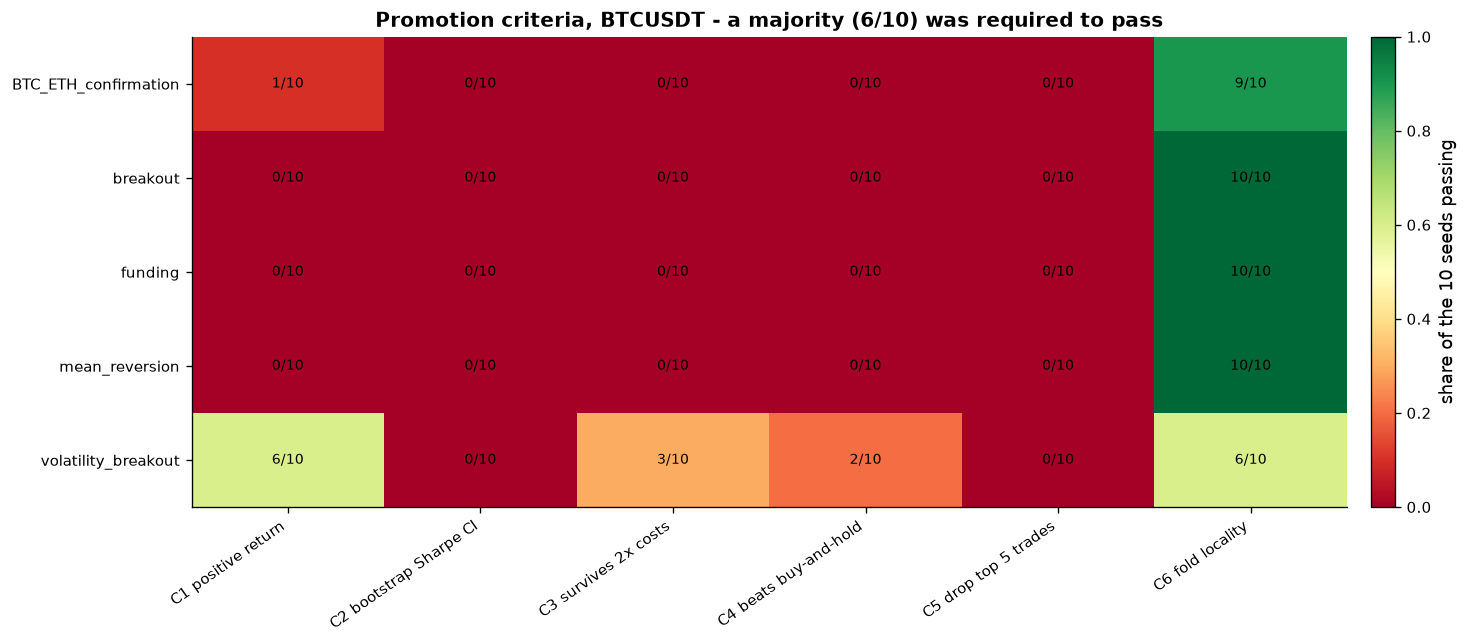

In [6]:
# --- J01: the criteria heat map ----------------------------------------------
piv = CRIT.filter(pl.col("symbol") == DASH["primary_symbol"])
fams = sorted(piv["family"].unique().to_list())
crits = list(dict.fromkeys(CRIT["criterion"].to_list()))
M = np.full((len(fams), len(crits)), np.nan)
REQ = np.full((len(fams), len(crits)), np.nan)
for r in piv.iter_rows(named=True):
    i, j = fams.index(r["family"]), crits.index(r["criterion"])
    M[i, j] = r["passed"] / max(1, r["of"])
    REQ[i, j] = r["required"] / max(1, r["of"])

fig, ax = plt.subplots(figsize=(12.4, 0.46 * len(fams) + 3.2))
im = ax.imshow(M, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
for i in range(len(fams)):
    for j in range(len(crits)):
        if np.isnan(M[i, j]):
            continue
        ax.text(
            j, i, f"{round(M[i, j] * 10)}/10", ha="center", va="center", fontsize=8.5, color="black"
        )
ax.set_xticks(range(len(crits)))
ax.set_xticklabels(crits, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(fams)))
ax.set_yticklabels(fams, fontsize=9)
ax.grid(visible=False)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label("share of the 10 seeds passing")
ax.set_title(
    f"Promotion criteria, {DASH['primary_symbol']} - a majority (6/10) was required to pass",
    fontsize=12,
)
fig.tight_layout()
show(
    fig,
    "j01_promotion_criteria",
    caption="Share of seeds passing each pre-registered promotion criterion, per family, "
    "on the primary asset.",
)

The map is overwhelmingly red, and the two criteria that fail most
consistently are the two that matter most economically: producing a positive
net return at all, and a bootstrap Sharpe interval that excludes zero. Some
families pass individual criteria on a minority of seeds -- which is exactly
what noise is expected to do: a criterion passed by chance one time in three
will pass on three or four seeds out of ten -- but the required majority is
essentially never reached.

The value of pre-registration is visible here. Had the thresholds been set
*after* looking, it would have been easy to notice that one family passes four
of six criteria and to argue that four is a reasonable bar. Because they were
fixed in advance, that argument is unavailable, and the failures can be
interpreted.

## 4. Correcting for the number of hypotheses — `INFERENTIAL — closed`

Test thirteen families at the 5% level and you expect roughly one false
success from chance alone. What remains once that is accounted for?

We apply both standard corrections, and reporting both is deliberate: had they
disagreed, the conclusion would depend on a methodological choice and would
have to be stated as such.

- **Holm-Bonferroni** controls the probability of even *one* false positive in
  the whole study (FWER) -- the conservative choice, appropriate where a
  single false claim is costly.
- **Benjamini-Hochberg** controls the expected share of false discoveries
  (FDR) -- more permissive, built for screening.

In [7]:
CORR = MT["corrections"]
holm = CORR["holm_bonferroni"]
bh = CORR["benjamini_hochberg"]

COMP = pl.DataFrame(
    {
        "correction": ["none (raw)", "Benjamini-Hochberg (FDR)", "Holm-Bonferroni (FWER)"],
        "n_tests": [CORR["n_tests"]] * 3,
        "n_rejected_at_alpha": [
            int(sum(1 for f in DASH["families"] if f["p_value"] < STUDY["alpha"])),
            int(bh["n_rejected"]),
            int(holm["n_rejected"]),
        ],
        "smallest_p_value": [
            float(min(f["p_value"] for f in DASH["families"])),
            float(min(bh["adjusted_p_values"].values())),
            float(min(holm["adjusted_p_values"].values())),
        ],
    }
)
save_table(
    COMP,
    "t04_multiple_testing",
    ctx,
    caption="Rejections at alpha = 0.05 before and after each multiple-testing correction.",
)
display(COMP)

print(f"\nTests counted        : {CORR['n_tests']}")
print(f"Holm rejections      : {holm['n_rejected']}")
print(f"BH rejections        : {bh['n_rejected']}")
print(f"Best family          : {CORR['best_family']}")

correction,n_tests,n_rejected_at_alpha,smallest_p_value
str,i64,i64,f64
"""none (raw)""",13,0,0.3455
"""Benjamini-Hochberg (FDR)""",13,0,0.9965
"""Holm-Bonferroni (FWER)""",13,0,1.0



Tests counted        : 13
Holm rejections      : 0
BH rejections        : 0
Best family          : volatility_breakout


In [8]:
# --- Sensitivity: what counts as "a test"? -----------------------------------
SENS = pl.DataFrame(
    [
        {
            "definition": k,
            "n_tests": v["n_tests"],
            "bonferroni_threshold": v["bonferroni_threshold"],
            "smallest_raw_p": v["smallest_raw_p_value"],
            "any_survive": v["any_survive"],
        }
        for k, v in MT["sensitivity"].items()
    ]
).sort("n_tests")
save_table(
    SENS,
    "t05_test_count_sensitivity",
    ctx,
    caption="Sensitivity of the conclusion to how the number of tested hypotheses is defined.",
)
display(SENS)
print(
    f"\nDefinitions under which SOME family survives: "
    f"{int(SENS['any_survive'].sum())} / {SENS.height}"
)

definition,n_tests,bonferroni_threshold,smallest_raw_p,any_survive
str,i64,f64,f64,bool
"""families""",13,0.003846,0.3455,false
"""family_x_asset""",22,0.002273,0.3455,false
"""family_x_asset_x_seed""",142,0.000352,0.3455,false
"""all_configurations_evaluated""",496500,1.0070e-7,0.3455,false



Definitions under which SOME family survives: 0 / 4


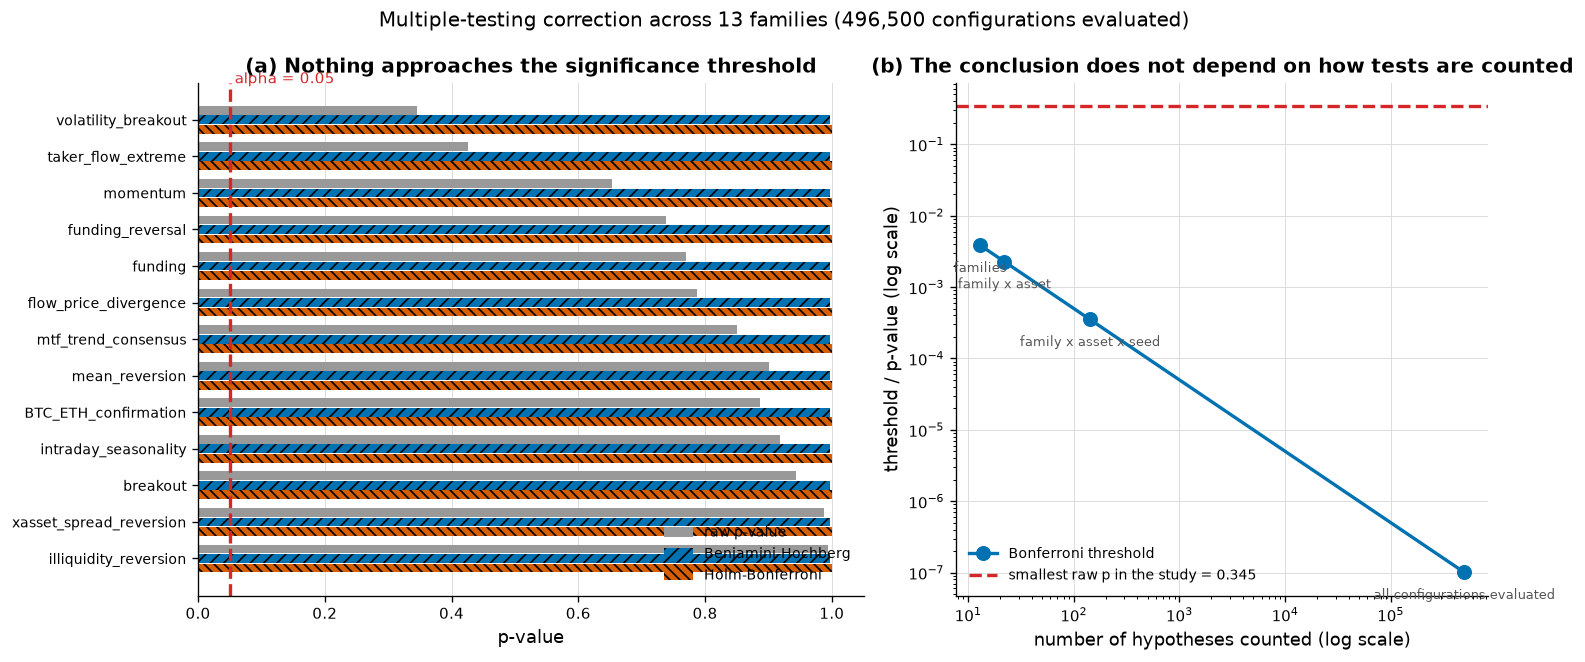

In [9]:
# --- J02: corrections and their sensitivity ----------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.2, 5.6), gridspec_kw={"width_ratios": [1.25, 1.0]})

order = sorted(holm["adjusted_p_values"], key=lambda k: holm["adjusted_p_values"][k])
raw_map = {}
for f in DASH["families"]:
    raw_map.setdefault(f["family"], []).append(f["p_value"])
raw = [min(raw_map[k]) for k in order]
hp = [holm["adjusted_p_values"][k] for k in order]
bp = [bh["adjusted_p_values"][k] for k in order]
yy = np.arange(len(order))
axA.barh(yy - 0.26, raw, height=0.24, color="#999999", label="raw p-value")
axA.barh(yy, bp, height=0.24, color="#0072B2", hatch="///", label="Benjamini-Hochberg")
axA.barh(yy + 0.26, hp, height=0.24, color="#D55E00", hatch="\\\\\\\\", label="Holm-Bonferroni")
axA.axvline(STUDY["alpha"], color="#D62728", lw=2.0, ls="--")
axA.text(STUDY["alpha"], -1.0, f" alpha = {STUDY['alpha']}", color="#D62728", fontsize=9)
axA.set_yticks(yy)
axA.set_yticklabels(order, fontsize=8.5)
axA.invert_yaxis()
axA.set_xlim(0, 1.05)
axA.set_xlabel("p-value")
axA.set_title("(a) Nothing approaches the significance threshold")
axA.legend(fontsize=8.5, loc="lower right")
axA.grid(axis="y", visible=False)

labels = SENS["definition"].to_list()
nt = SENS["n_tests"].to_numpy()
thr = SENS["bonferroni_threshold"].to_numpy()
smallest = float(SENS["smallest_raw_p"][0])
axB.plot(nt, thr, marker="o", ms=8, lw=2.0, color="#0072B2", label="Bonferroni threshold")
axB.axhline(
    smallest,
    color="#D62728",
    lw=2.0,
    ls="--",
    label=f"smallest raw p in the study = {smallest:.3f}",
)
axB.set_xscale("log")
axB.set_yscale("log")
for x, y, lab in zip(nt, thr, labels, strict=True):
    axB.annotate(
        lab.replace("_", " "),
        xy=(x, y),
        xytext=(0, -16),
        textcoords="offset points",
        fontsize=7.5,
        ha="center",
        color="#555555",
    )
axB.set_xlabel("number of hypotheses counted (log scale)")
axB.set_ylabel("threshold / p-value (log scale)")
axB.set_title("(b) The conclusion does not depend on how tests are counted")
axB.legend(fontsize=8.5, loc="lower left")

fig.suptitle(
    f"Multiple-testing correction across {CORR['n_tests']} families "
    f"({STUDY['n_configurations_evaluated']:,} configurations evaluated)",
    fontsize=12,
)
fig.tight_layout()
show(
    fig,
    "j02_multiple_testing",
    caption="Raw and adjusted p-values per family (a), and the sensitivity of the "
    "Bonferroni threshold to how the number of hypotheses is counted (b).",
)

Panel (a) shows both corrections pushing every adjusted p to the top of the
scale -- but that is not the informative part: the grey bars were already far
from the threshold before correcting.

Panel (b) closes the standard objection to any multiple-testing argument: that
the number of tests was chosen to suit. One can count thirteen (one per
family), twenty-two (family by asset), one hundred and forty-two (adding
seeds), or nearly half a million (every configuration evaluated). Four orders
of magnitude, Bonferroni thresholds from roughly 4e-3 down to 1e-7 -- and
**every one of them sits below the smallest raw p observed**. The red dashed
line stays above the blue curve across the whole range: no version of this
argument exists in which some family survives.

## 5. How likely is the best result to be an artefact? — `INFERENTIAL — closed`

P-values answer "could this have arisen by chance?" for one hypothesis. Two
purpose-built diagnostics answer the question a backtester actually faces.

The **deflated Sharpe** asks: given that we tried N configurations, what
Sharpe would the best of them reach *by luck alone*, and does the observed
best clear that bar?

The **PBO** asks something more direct and harder to argue with: split the
observation series in two many times, pick the in-sample best, and measure how
often that pick lands in the *bad half* out of sample. A PBO near **0.5**
means selection carries no information: the in-sample winner is a coin flip
out of sample.

In [10]:
ds = CORR["deflated_sharpe"]
pbo = CORR["probability_of_backtest_overfitting"]

DS = pl.DataFrame(
    [
        {
            "scenario": k,
            "n_trials": v["n_trials"],
            "observed_sharpe_per_obs": v["observed_sharpe_per_observation"],
            "benchmark_sharpe_per_obs": v["benchmark_sharpe_per_observation"],
            "deflated_sharpe": v["deflated_sharpe"],
            "probability_best_is_spurious": v["probability_best_is_spurious"],
        }
        for k, v in ds.items()
    ]
)
save_table(
    DS,
    "t06_deflated_sharpe",
    ctx,
    caption="Deflated Sharpe of the study's best family under two definitions of the "
    "number of trials.",
)
display(DS)

print(f"\nPBO                         : {pbo['pbo']:.4f}")
print(f"  splits evaluated          : {pbo['n_splits']}")
print(f"  configurations compared   : {pbo['n_configurations']}")
print(f"  observations              : {pbo['n_observations']:,}")
print("\nInterpretation of PBO:")
print("  0.0 = the in-sample winner always wins out of sample (no overfitting)")
print("  0.5 = the in-sample winner is a coin flip out of sample (selection is uninformative)")
print("  1.0 = the in-sample winner always LOSES out of sample (systematic overfitting)")

scenario,n_trials,observed_sharpe_per_obs,benchmark_sharpe_per_obs,deflated_sharpe,probability_best_is_spurious
str,i64,f64,f64,f64,f64
"""family_selection""",13,0.002071,0.008089,0.139482,0.860518
"""all_configurations_evaluated""",496500,0.002071,0.022451,0.000123,0.999877



PBO                         : 0.4857
  splits evaluated          : 70
  configurations compared   : 13
  observations              : 32,385

Interpretation of PBO:
  0.0 = the in-sample winner always wins out of sample (no overfitting)
  0.5 = the in-sample winner is a coin flip out of sample (selection is uninformative)
  1.0 = the in-sample winner always LOSES out of sample (systematic overfitting)


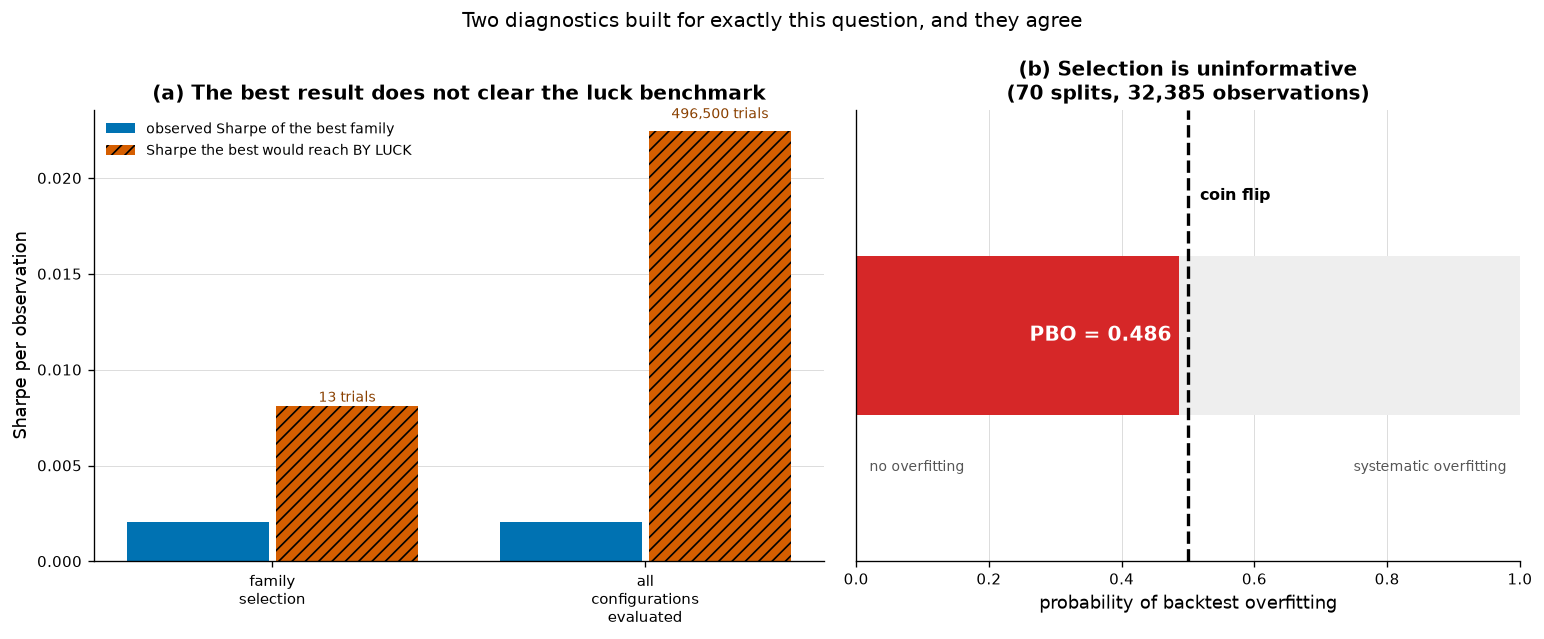

In [11]:
# --- J03: deflated Sharpe and PBO --------------------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.0, 5.4), gridspec_kw={"width_ratios": [1.1, 1.0]})

scen = DS["scenario"].to_list()
obs = DS["observed_sharpe_per_obs"].to_numpy()
bench = DS["benchmark_sharpe_per_obs"].to_numpy()
xx = np.arange(len(scen))
axA.bar(xx - 0.2, obs, width=0.38, color="#0072B2", label="observed Sharpe of the best family")
axA.bar(
    xx + 0.2,
    bench,
    width=0.38,
    color="#D55E00",
    hatch="///",
    label="Sharpe the best would reach BY LUCK",
)
for i in range(len(scen)):
    axA.text(
        i + 0.2,
        bench[i] * 1.03,
        f"{DS['n_trials'][i]:,} trials",
        ha="center",
        fontsize=8.5,
        color="#8A4000",
    )
axA.set_xticks(xx)
axA.set_xticklabels([s.replace("_", "\n") for s in scen], fontsize=9)
axA.set_ylabel("Sharpe per observation")
axA.set_title("(a) The best result does not clear the luck benchmark")
axA.legend(fontsize=8.5, loc="upper left")
axA.grid(axis="x", visible=False)

val = float(pbo["pbo"])
axB.barh([0], [1.0], color="#EEEEEE", height=0.42)
axB.barh([0], [val], color="#D62728", height=0.42)
axB.axvline(0.5, color="black", lw=2.0, ls="--")
axB.text(0.5, 0.36, "  coin flip", fontsize=9.5, fontweight="bold")
axB.text(
    val,
    0,
    f" PBO = {val:.3f} ",
    va="center",
    ha="right",
    fontsize=12,
    fontweight="bold",
    color="white",
)
axB.text(0.02, -0.36, "no overfitting", fontsize=8.5, color="#555555")
axB.text(0.98, -0.36, "systematic overfitting", fontsize=8.5, color="#555555", ha="right")
axB.set_xlim(0, 1)
axB.set_ylim(-0.6, 0.6)
axB.set_yticks([])
axB.set_xlabel("probability of backtest overfitting")
axB.set_title(
    f"(b) Selection is uninformative\n({pbo['n_splits']} splits, "
    f"{pbo['n_observations']:,} observations)"
)
axB.grid(axis="y", visible=False)

fig.suptitle("Two diagnostics built for exactly this question, and they agree", fontsize=12)
fig.tight_layout()
show(
    fig,
    "j03_deflated_sharpe_pbo",
    caption="Deflated Sharpe under two trial counts (a) and the probability of backtest "
    "overfitting (b).",
)

Panel (a) makes the deflation argument concrete. Counting only the thirteen
families as trials, the Sharpe that *the best of thirteen* would reach by luck
already exceeds what the best family actually achieved -- the observed best is
not merely unimpressive, it underperforms chance. Counting all 496,500
evaluated configurations, the luck benchmark rises by an order of magnitude
and the probability that the best result is spurious approaches certainty.

Panel (b) is the cleanest single number in the thesis. The PBO sits at
**0.5**: picking the in-sample best confers essentially no advantage out of
sample. It is the mechanism notebook 04 observed fold by fold, now measured
over the whole study -- what a search operating on noise looks like from the
inside.

Worth stating what PBO does *not* say: not that the strategies are bad in some
absolute sense, nor that the implementation is broken. It says **the ranking
produced by in-sample performance does not transfer** -- the search cannot be
used to pick a winner, however good the candidates might individually be.

## 6. Does conditioning on regime rescue anything? — `INFERENTIAL — closed (exploratory)`

A strategy could hold a real edge that only appears in certain market
conditions and is averaged away unconditionally. Does splitting by volatility
regime reveal one?

Each family is re-evaluated inside each regime cell -- with a minimum cell
size so nothing is tested on a handful of bars -- and the resulting p-values
are corrected across all cells. The artifact itself labels this analysis
**exploratory**: it multiplies the number of tests, making it the likeliest
place in the whole study for a false positive to appear. That none does is,
for that very reason, a strong statement.

In [12]:
CELLS_ = pl.DataFrame(REG["cells"]).sort("p_value")
save_table(
    CELLS_.head(20),
    "t07_regime_cells_top20",
    ctx,
    caption="The twenty most favourable family-by-regime cells, ranked by raw p-value.",
)
display(CELLS_.head(15))

rc = REG["correction"]
print(f"\nStatus                    : {REG['status']}")
print(
    f"Cells tested              : {rc['n_cells']} (testable: {rc['n_testable_cells']}, "
    f"excluded as too small: {rc['n_excluded_small_cells']}, min bars: {rc['min_cell_bars']})"
)
print(f"Holm rejections           : {rc['holm_bonferroni'].get('n_rejected', 0)}")
print(f"Benjamini-Hochberg        : {rc['benjamini_hochberg'].get('n_rejected', 0)}")
print(f"Survivors                 : {len(rc['survivors'])}")
print(f"Promoted candidate        : {REG['candidate']}")
print(f"\nSmallest raw p across all cells: {float(CELLS_['p_value'].min()):.4f}")
print(
    f"Cells with a positive total return: "
    f"{int((CELLS_['total_return'] > 0).sum())} / {CELLS_.height}"
)

family,gate,dimension,regime,n_bars,share_of_bars,mean_bar_return,total_return,sharpe_annualised,p_value
str,str,str,str,i64,f64,f64,f64,f64,f64
"""volatility_breakout""","""R3""","""volatility""","""low""",19652,0.606824,0.000019,0.412484,1.011615,0.077
"""taker_flow_extreme""","""S2""","""trend""","""up""",16544,0.510854,0.000009,0.159247,0.855474,0.1155
"""flow_price_divergence""","""S2""","""volatility""","""high""",4098,0.12654,0.00001,0.04261,1.366865,0.124
"""volatility_breakout""","""R3""","""trend""","""up""",16544,0.510854,0.000025,0.441641,0.94012,0.1315
"""funding""","""R3""","""volatility""","""low""",19652,0.606824,0.00001,0.179027,0.540425,0.2215
…,…,…,…,…,…,…,…,…,…
"""momentum""","""R2""","""trend""","""up""",16544,0.510854,0.000013,0.158978,0.418975,0.304
"""taker_flow_extreme""","""S2""","""volatility""","""low""",19652,0.606824,0.000003,0.046153,0.318755,0.331
"""taker_flow_extreme""","""S2""","""volatility""","""medium""",8635,0.266636,0.000005,0.040171,0.421096,0.356



Status                    : EXPLORATORY - generated hypotheses only, nothing promoted
Cells tested              : 65 (testable: 65, excluded as too small: 0, min bars: 500)
Holm rejections           : 0
Benjamini-Hochberg        : 0
Survivors                 : 0
Promoted candidate        : None

Smallest raw p across all cells: 0.0770
Cells with a positive total return: 16 / 65


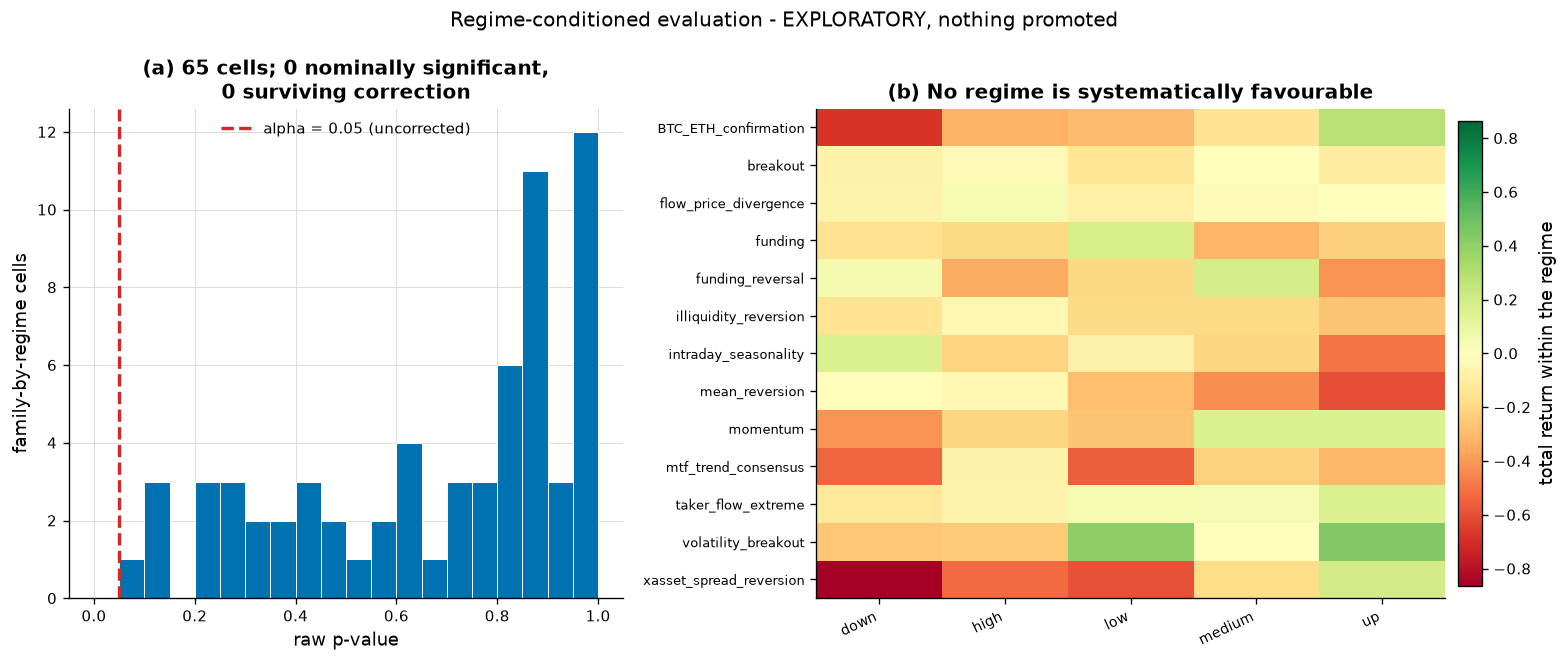

In [13]:
# --- J04: regime cells --------------------------------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.2, 5.6), gridspec_kw={"width_ratios": [1.0, 1.2]})

p = CELLS_["p_value"].to_numpy()
axA.hist(p, bins=20, range=(0, 1), color="#0072B2", edgecolor="white", linewidth=0.6)
axA.axvline(
    STUDY["alpha"],
    color="#D62728",
    lw=2.0,
    ls="--",
    label=f"alpha = {STUDY['alpha']} (uncorrected)",
)
n_nominal = int((p < STUDY["alpha"]).sum())
axA.set_xlabel("raw p-value")
axA.set_ylabel("family-by-regime cells")
axA.set_title(
    f"(a) {rc['n_cells']} cells; {n_nominal} nominally significant,\n"
    f"{len(rc['survivors'])} surviving correction"
)
axA.legend(fontsize=9)

regs = sorted(CELLS_["regime"].unique().to_list())
fams_r = sorted(CELLS_["family"].unique().to_list())
G = np.full((len(fams_r), len(regs)), np.nan)
for r in CELLS_.iter_rows(named=True):
    G[fams_r.index(r["family"]), regs.index(r["regime"])] = r["total_return"]
vmax = float(np.nanmax(np.abs(G)))
im = axB.imshow(G, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
axB.set_xticks(range(len(regs)))
axB.set_xticklabels(regs, rotation=25, ha="right", fontsize=8.5)
axB.set_yticks(range(len(fams_r)))
axB.set_yticklabels(fams_r, fontsize=8)
axB.grid(visible=False)
cb = fig.colorbar(im, ax=axB, fraction=0.035, pad=0.02)
cb.set_label("total return within the regime")
axB.set_title("(b) No regime is systematically favourable")

fig.suptitle("Regime-conditioned evaluation - EXPLORATORY, nothing promoted", fontsize=12)
fig.tight_layout()
show(
    fig,
    "j04_regime_conditioned",
    caption="Distribution of raw p-values across family-by-regime cells (a) and the total "
    "return of each cell (b). No cell survives multiple-testing correction.",
)

The histogram in panel (a) is the diagnostic to read. Under the global null --
no family has an edge in any regime -- p-values are uniform: a flat histogram,
with about 5% of cells below alpha by chance alone. That is close to what is
observed, and **no cell survives correction**. A real conditional effect would
leave an excess of mass near zero that correction cannot erase; there is none.
Panel (b) says the same economically: returns scatter across regimes with no
systematically favourable column -- what noise looks like arranged in a grid.

The honest reservation: a real effect that is small and confined to a narrow
regime could escape this analysis -- conditioning splits the sample, and small
cells have less power. The section rules out *strong* conditional edges, not
every conceivable one. That is why the artifact labels it exploratory, and why
no candidate was promoted from it.

## 7. The frozen holdout: opened, recorded, deliberately unpublished — `DESCRIPTIVE`

This section reports a **process decision**, not a number -- and that
distinction is the content.

**What happened.** The partition `[2026-01-01, 2026-07-01)` was frozen at the
project's start and never touched during exploration, feature design, family
selection or parameter search. It was opened **once**, on 2026-08-13, on a
candidate whose selection rule and parameters were committed *before* the
opening -- a candidate the study-level correction had **already rejected**.
That reading exists on disk.

**Why it is not published here.** The repository records the opening as
`HOLDOUT_LOCKED`: the subsequent provenance audit established that the
authorization the protocol required did not exist at opening time (the only
control bearing that name is a *publication* lock, introduced afterwards), and
a nine-requirement audit remains open before the number may be cited. The full
chronology, with its evidence, lives in
`docs/methodology/holdout_audit_status.md`.

The important part: **history was not rewritten to tidy this up.** Rewriting
it would have destroyed exactly the property that makes an opening auditable
-- that the commit freezing the candidate verifiably precedes the one
recording the result. The commit chain *is* the evidence.

**Why the conclusion does not depend on it.** The holdout was to be the
confirmatory test of an already-rejected candidate. This thesis's result is
the thirteen-family map with zero survivors and a PBO around 0.5 -- complete
without opening the partition. Publishing the reading would change a
paragraph's emphasis, not the conclusion. What is permanently lost is a clean
confirmation on this history: the partition is consumed, and any future family
will need new data.

In [14]:
lock_rows = [
    {
        "control": "Artifact layer",
        "state": "study_dashboard.json contains no holdout metrics unless --include-holdout is passed",
        "verified": DASH.get("holdout") is None,
    },
    {
        "control": "Service layer",
        "state": "publication requires PERP_LAB_HOLDOUT_PUBLICATION == AUDITED_OPEN_FINAL_HOLDOUT",
        "verified": DASH.get("holdout_publication") != "PUBLISHED",
    },
    {
        "control": "This notebook",
        "state": "reads no holdout metrics; multiple-testing artifact confirms holdout_accessed = False",
        "verified": MT["holdout_accessed"] is False,
    },
]
LOCKS = pl.DataFrame(lock_rows)
save_table(
    LOCKS,
    "t08_holdout_locks",
    ctx,
    caption="Independent controls preventing publication of the frozen-holdout reading.",
)
display(LOCKS)

print(f"Holdout publication state : {DASH['holdout_publication']}")
print(f"Holdout payload in dashboard : {DASH.get('holdout')}")
print(f"Holdout accessed by the study-level analysis : {MT['holdout_accessed']}")
print(f"\nAll locks engaged: {bool(LOCKS['verified'].all())}")
print("\nNo holdout metric is computed, displayed or exported by this notebook.")

control,state,verified
str,str,bool
"""Artifact layer""","""study_dashboard.json contains …",true
"""Service layer""","""publication requires PERP_LAB_…",true
"""This notebook""","""reads no holdout metrics; mult…",true


Holdout publication state : AUDIT_PENDING
Holdout payload in dashboard : None
Holdout accessed by the study-level analysis : False

All locks engaged: True

No holdout metric is computed, displayed or exported by this notebook.


## 8. What a negative of this shape establishes — `DESCRIPTIVE`

The study found nothing. What, exactly, has been learned?

Each claim below carries, besides its evidence and scope limit, **the result
that would have contradicted it**: that is what separates a defensible
negative from a comfortable one. If no conceivable observation could have
overturned a conclusion, that conclusion was not claiming anything.

In [15]:
conclusions = [
    {
        "id": "C1",
        "claim": "No family in this study has a demonstrable edge on BTC/ETH perpetuals at 1h",
        "strength": "Strong",
        "basis": f"{FAM['family'].n_unique()} families, {STUDY['n_units']} units, smallest raw "
        f"p-value {float(FAM['p_value'].min()):.3f} before any correction",
        "scope_limit": "1h timeframe, 2020-2025, these two assets, these rule families",
        "would_have_contradicted": "A family with raw p < 0.05 sustained on both assets",
    },
    {
        "id": "C2",
        "claim": "The conclusion is invariant to how the number of hypotheses is counted",
        "strength": "Strong",
        "basis": f"t05: {SENS.height} counting conventions spanning "
        f"{int(SENS['n_tests'].min())}..{int(SENS['n_tests'].max()):,} tests, none yields a survivor",
        "scope_limit": "Applies to the family-level tests actually run",
        "would_have_contradicted": "Any reasonable denominator under which some family survives",
    },
    {
        "id": "C3",
        "claim": "In-sample selection carries essentially no out-of-sample information",
        "strength": "Strong",
        "basis": f"PBO = {pbo['pbo']:.3f} over {pbo['n_splits']} splits; deflated Sharpe puts the "
        f"best family spurious with probability "
        f"{ds['family_selection']['probability_best_is_spurious']:.2f}",
        "scope_limit": "Measured on this study's configuration set",
        "would_have_contradicted": "PBO clearly below 0.5, or a positive deflated Sharpe with a "
        "low spurious probability",
    },
    {
        "id": "C4",
        "claim": "Regime conditioning rescues no family",
        "strength": "Moderate",
        "basis": f"{rc['n_cells']} cells, {len(rc['survivors'])} survivors after correction; "
        "p-value histogram consistent with the global null",
        "scope_limit": "Conditioning cuts power; a weak, narrow effect could escape",
        "would_have_contradicted": "An excess of small p-values beyond the null expectation, "
        "with Holm survivors",
    },
    {
        "id": "C5",
        "claim": "The evolutionary search offers no advantage over Random Search here",
        "strength": "Moderate",
        "basis": "Notebook 04: budget parity verified; 1 of 5 families nominally significant, "
        "consistent with chance across five tests",
        "scope_limit": "Spaces of this size; says nothing about far larger spaces",
        "would_have_contradicted": "A paired GA-RS interval excluding zero in the GA's favour, "
        "consistently across families",
    },
    {
        "id": "C6",
        "claim": "The apparatus is sound, so the negative speaks about the market, not the tooling",
        "strength": "Strong",
        "basis": "Notebook 02: causality guarantees G1-G7 pass on real data; notebook 03: "
        "execution, cost and fold-geometry guards verified and failing closed",
        "scope_limit": "Costs remain provisional (ADR 0005)",
        "would_have_contradicted": "A guard failing open, or the planted leak going undetected",
    },
]
CONC = pl.DataFrame(conclusions)
save_table(
    CONC,
    "t09_conclusions",
    ctx,
    caption="Claims the study supports, with their evidence, scope limits, and the "
    "result that would have falsified each.",
)
display(CONC)
print(f"\nArtifacts written under : {ctx.figures_dir} | {ctx.tables_dir}")

id,claim,strength,basis,scope_limit,would_have_contradicted
str,str,str,str,str,str
"""C1""","""No family in this study has a …","""Strong""","""13 families, 284 units, smalle…","""1h timeframe, 2020-2025, these…","""A family with raw p < 0.05 sus…"
"""C2""","""The conclusion is invariant to…","""Strong""","""t05: 4 counting conventions sp…","""Applies to the family-level te…","""Any reasonable denominator und…"
"""C3""","""In-sample selection carries es…","""Strong""","""PBO = 0.486 over 70 splits; de…","""Measured on this study's confi…","""PBO clearly below 0.5, or a po…"
"""C4""","""Regime conditioning rescues no…","""Moderate""","""65 cells, 0 survivors after co…","""Conditioning cuts power; a wea…","""An excess of small p-values be…"
"""C5""","""The evolutionary search offers…","""Moderate""","""Notebook 04: budget parity ver…","""Spaces of this size; says noth…","""A paired GA-RS interval exclud…"
"""C6""","""The apparatus is sound, so the…","""Strong""","""Notebook 02: causality guarant…","""Costs remain provisional (ADR …","""A guard failing open, or the p…"



Artifacts written under : reports\figures\closure | reports\tables\closure


It is easy to read this result as "markets are efficient" or "algorithmic
trading does not work". We have demonstrated neither.

What we have demonstrated is narrower and, we believe, more useful: within a
well-bounded space -- thirteen interpretable families, two liquid perpetuals,
hourly bars, six years, a realistic cost model -- a rigorous search finds
nothing that survives an honest count of how many times we looked. The bound
matters as much as the finding: each of those limits is a place where another
study, on other data or another frequency, could reach a different answer.
Scope limits travel next to each claim, not buried.

We trust this negative for three reasons, and we state them as our decisions
rather than as circumstances: we validated the tooling before using it and
confirmed it catches a deliberately planted leak instantly (notebooks 02 and
03); we gave the search a fair chance, with the budget matched and verified in
every family; and we cross-checked the verdict with three methodologically
independent diagnostics -- hypothesis tests, deflated Sharpe and PBO -- that
could have disagreed and did not.

What would change the conclusion: higher-frequency data, where microstructure
lives; a richer hypothesis space; assets with less institutional
participation; or a maker-only cost structure. Each is a concrete, falsifiable
extension, not a hedge.

On the meta-labeling layer, one note with its label in front:
**INFRASTRUCTURE / EXPLORATORY (methodology contract section 5; ADR 0017).**
Since the study closed with no eligible primary, the meta-labeling gate never
opened; we ran the layer on real data anyway under that contract so RQ3 would
not remain without evidence. The outcome -- economic improvement in every fold
with ROC-AUC around 0.5: all of the gain comes from abstaining, none from
predicting -- is a diagnostic of the tooling and the space, **not a finding
about the rejected primary**. Those runs sit outside this closure's frozen
denominator; any future claim built on them would have to count its
model-by-fold fits. Notebook 06 narrates it in full.

The methodological contribution is the most transferable: not the verdict on
any family, but the demonstration that the verdict can be *trusted* -- every
step from raw data to conclusion is auditable, every guard fails closed
rather than warning, and the one moment the process wobbled was recorded in
the open instead of smoothed away.

### From the local questions to the thesis

| Local question | Feeds | How |
|---|---|---|
| Q1 (test count) | RQ5 (robustness) | the denominator sensitivity is the verdict's robustness proof |
| Q2 (promotion criteria) | RQ1 (net profitability) | the six economic bars operationalise RQ1 |
| Q3 (corrections) | RQ1 | RQ1's "no", corrected for having looked thirteen times |
| Q4 (artefact?) | RQ1 + RQ5 | DSR and PBO quantify how much to trust the best result |
| Q5 (regime) | RQ4 (regime dependence) | direct answer: no conditional rescue |
| Q6 (scope of the negative) | cross-cutting | fixes what the thesis does and does not claim |

RQ2 (GA vs RS) is answered in notebook 04; RQ3 (meta-labeling), in the
infrastructure note above and in notebook 06.

---

**What this notebook leaves behind, and where it goes.** Figures `j01`
(promotion criteria), `j02` (multiple testing and count sensitivity), `j03`
(deflated Sharpe and PBO) and `j04` (regime), plus tables `t01`-`t09`, all
under `reports/{figures,tables}/closure/`. They feed chapter 6 (results: j01,
j02, t01-t05), chapter 7 (limitations: j02b, t08 and the holdout section) and
chapter 8 (discussion: j03, j04, t09). Notebook 06 takes the baton: the
supervised layer on real data, and what separates economic improvement from
predictive skill.